# K-nearest neighbours 

## Importación de librerías, paquetes y definición de constantes

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from sklearn.neighbors import KNeighborsClassifier
# Métricas
from utils import get_classifier_metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# Optimizar
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV


## Generamos los conjuntos de train y test

In [30]:
X_train = pd.read_csv("../data/processed/xtrain-knn.csv")
y_train = pd.read_csv("../data/processed/ytrain-knn.csv")
X_test =  pd.read_csv("../data/processed/xtest-knn.csv")
y_test =  pd.read_csv("../data/processed/ytest-knn.csv")

X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.095238,0.36,-0.606061,-0.285714,0.000000,0.357143,0.047619,0.075221,0.421053,0.000000,-0.0625
1,-0.285714,-0.48,0.151515,0.285714,-0.238095,-0.357143,0.166667,-0.265487,0.526316,-0.444444,-0.5000
2,1.714286,0.12,1.363636,3.142857,2.142857,-0.571429,-0.571429,0.707965,-1.578947,1.166667,1.0000
3,-0.190476,0.28,0.909091,1.285714,3.523810,-0.642857,-0.595238,-0.902655,-0.526316,2.277778,0.8750
4,-0.285714,1.88,-0.636364,-0.142857,-0.857143,0.428571,0.238095,0.110619,0.000000,-0.388889,-0.3125
...,...,...,...,...,...,...,...,...,...,...,...
1082,-0.285714,0.32,0.000000,7.142857,-0.428571,1.500000,1.952381,0.575221,0.315789,-0.722222,-0.5000
1083,0.238095,0.62,1.060606,-0.285714,1.571429,-0.071429,1.333333,0.088496,-0.789474,-0.444444,-0.6875
1084,0.380952,0.46,-0.303030,-0.285714,1.047619,-0.071429,0.238095,-0.265487,-0.894737,-0.277778,0.5000
1085,0.476190,-0.12,0.818182,2.571429,1.047619,-0.785714,-0.690476,-0.415929,-0.526316,-0.166667,1.1875


## Modelado y Ajuste

In [31]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
y_pred_test = knn_model.predict(X_test)

In [33]:
y_pred_train = knn_model.predict(X_train)

## Métricas

In [34]:
accuracy_score(y_test, y_pred_test)

0.8125

In [35]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.25      0.08      0.12        13
           1       0.85      0.95      0.89       222
           2       0.50      0.27      0.35        37

    accuracy                           0.81       272
   macro avg       0.53      0.43      0.45       272
weighted avg       0.77      0.81      0.78       272



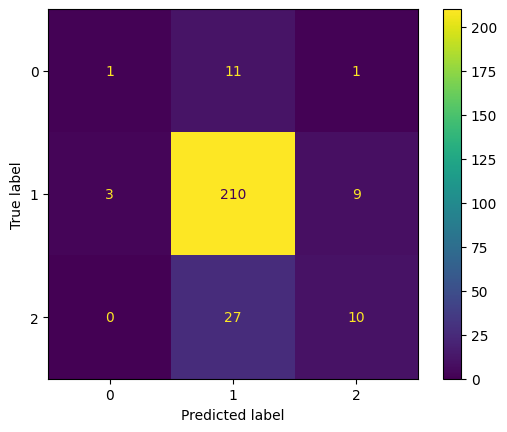

In [36]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### El modelo predice muy bien sobre los vinos de clase media pero falla al predecir sobre los vinos de clase baja y alta, si observamos el conjunto de datos puede ser porque la mayoría de elementos pertenecen a esa clase. Posible prueba, realizar un modelo con rangos diferentes para la calidad del vino

## Optimización del modelo con `GridSearch`

### Parámetros para la cuadrícula

In [37]:
param_grid = {'n_neighbors': [3, 5, 10, 15, 30, 50],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'metric': ['cityblock', 'cosine', 'euclidean', 'haversine', 'l1', 'l2', 'manhattan', 'nan_euclidean']
              }
grid_search = GridSearchCV(estimator=knn_model,
                           param_grid=param_grid,
                           cv=5,
                           refit='accuracy'
                           )


### Entrenamiento de la cuadrícula

In [38]:
grid_search.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change t

,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'metric': ['cityblock', 'cosine', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,'accuracy'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,50


### Mejores párametros

In [39]:
grid_search.best_params_

{'algorithm': 'auto',
 'metric': 'cityblock',
 'n_neighbors': 50,
 'weights': 'distance'}

In [40]:
grid_knn = grid_search.best_estimator_
y_pred_test = grid_knn.predict(X_test)
y_pred_train = grid_knn.predict(X_train)

### Métricas de la cuadrícula

In [41]:
accuracy_score(y_test, y_pred_test)

0.8198529411764706

In [42]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.83      0.99      0.90       222
           2       0.50      0.08      0.14        37

    accuracy                           0.82       272
   macro avg       0.44      0.36      0.35       272
weighted avg       0.74      0.82      0.75       272



C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

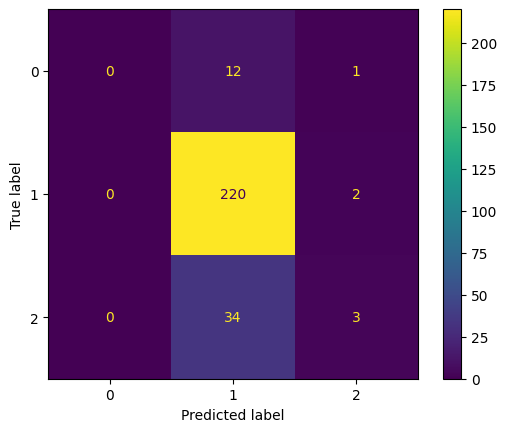

In [43]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### Probamos con diferentes valores de k

In [ ]:
acurracy = []
for k in range(1, 21):
    knn_model_optimus = KNeighborsClassifier(n_neighbors=k, weights='distance', algorithm='auto', metric='cityblock', n_jobs=-1)
    knn_model_optimus.fit(X_train, y_train)
    y_pred_test = knn_model_optimus.predict(X_test)
    y_pred_train = knn_model_optimus.predict(X_train)
    acurracy.append(accuracy_score(y_test, y_pred_test))

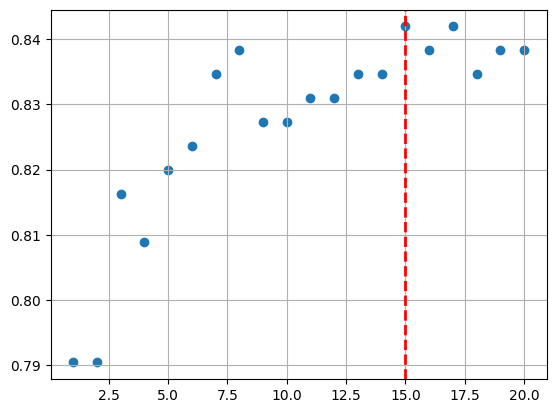

In [ ]:
k = np.arange(1, 21)
plt.scatter(x=k, y=acurracy)
plt.axvline(x=15, color='red', linestyle='--', linewidth=2)
plt.grid()
plt.show()

### Observamos que el valor de máximo accuracy lo obtenemos para k=15 y k=17, con el resto de parámetros fijados

In [46]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.85      0.98      0.91       222
           2       0.67      0.27      0.38        37

    accuracy                           0.84       272
   macro avg       0.50      0.42      0.43       272
weighted avg       0.78      0.84      0.80       272



C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

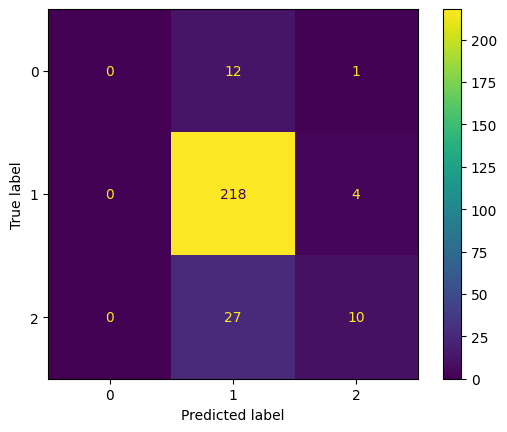

In [47]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Conclusiones

>- Parece que el conjunto de datos esta sesgado hacia la clase media(1), podemos redistribuir los datos para tener mejores predicciones en el resto de clases
>- Al optimizar, el modelo mejora en precision y recall para la clase 2 cuanto mayor es "K", no mejora para la clase 0. Seguramente se debe a la distribución de la variable 'label'
>- Podemos decir que el modelo es bueno pero no suficiente

## Guardado de modelos

In [49]:
model = knn_model
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelo-knn.pkl', 'wb') as file:
    pickle.dump(model, file)